# 07 · UMAP

PCA gave you straight axes you could read off as loadings. UMAP gives you a picture —
more legible, and much easier to over-read.

| | |
|---|---|
| **1** | Choose the features, and build the graph |
| **2** | Run UMAP |
| **3** | Colour it by everything you know |
| **4** | What UMAP does *not* preserve |
| **5** | What the picture actually says |
| **6** | Save the embedding |

:::{note}
These are the **controls** — every DMSO and PBS cell, and nothing else. Neither is a
treatment, so a UMAP of them should show the cells arranging themselves by time and by
state, and should show nothing at all about which of the two they came from.
:::

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import math

plt.rcParams.update({          # the house style, no package needed
    "figure.dpi": 110, "savefig.dpi": 300, "savefig.bbox": "tight",
    "font.size": 9, "axes.titlesize": 10, "axes.labelsize": 9,
    "axes.spines.top": False, "axes.spines.right": False, "axes.grid": False,
    "legend.frameon": False, "pdf.fonttype": 42, "ps.fonttype": 42,
})

def panel_grid(n, *, ncols=3, size=(3.6, 3.0)):
    """A figure with `n` axes on a grid, the unused ones removed."""
    nrows = -(-n // ncols)
    fig, axes = plt.subplots(nrows, ncols, squeeze=False,
                             figsize=(size[0] * ncols, size[1] * nrows))
    flat = axes.ravel()
    for ax in flat[n:]:
        ax.remove()
    return fig, flat[:n]
pd.set_option("display.width", 140)

# The tables live here on Euler. Change this line if your copy is elsewhere.
DATA = Path("/cluster/project/mcsliberali/file_outputs")

cells = sc.read_h5ad(DATA / "mcs2026_controls_downstream.h5ad")
print(f"{cells.n_obs:,} cells x {cells.n_vars} markers")
print(f"  conditions: {sorted(cells.obs.condition.astype(str).unique())}, "
      f"{cells.obs.well.nunique()} wells")
print(f"  obsm: {list(cells.obsm)}")

97,177 cells x 38 markers
  conditions: ['DMSO', 'PBS'], 32 wells
  obsm: ['X_pca']


## 1 · Choose the features, and build the graph

UMAP does not work on the cells directly. It works on a **graph** — each cell joined to
its nearest neighbours — and the embedding is an attempt to draw that graph on a page.
Everything you can change about a UMAP, you change here, and the first thing to change is
**which numbers decide who is a neighbour**.

[Chapter 06](06_pca.ipynb) surveyed all 38 markers and found the largest axis of variation
was how brightly a cell stained. That is the right answer to the question it asked and the
wrong basis for this one: a cell's *identity* should not depend on how bright its
lysosomes are.

So cut to the markers that define identity — eight transcription factors and one receptor,
each marking a lineage a naive human embryonic stem cell can become:

| markers | lineage |
|---|---|
| Oct4, Nanog, Sox2 | **pluripotent** — the starting state |
| GATA3 | **trophectoderm** |
| GATA4, GATA6, SOX17, PDGFRa | **hypoblast** (primitive endoderm) |

Below, we will create a view only containing the intensity values for the markers that set the identity of the cell lineages. 

This simplifies the UMAP, as it forces cells into the groups we expect to obtain, and reduces noise that may come from other markers, but also reduces our ability to see new cell states and efects.

We basically want to reduce the dimensionality of the dataset and only include the most informative markers. This step is commonly known as feature selection in scRNAseq, but in imaging data is much more drastic.

In [3]:
# Here we set the markers from the identity panel
identity = [m for m in cells.uns["panels"]["identity"] if m in set(cells.var_names)]

# Here we subset the X based on those markers and store it as a new matrix in obsm
cells.obsm["X_identity"] = np.asarray(cells[:, identity].X)

cells.var.loc[identity, ["marker", "round", "channel", "species", "failed"]]

,marker,round,channel,species,failed
Oct4,Oct4,1,Texas Red,Mouse,False
Nanog,Nanog,1,FITC,Goat,False
Sox2,Sox2,3,Cy5,Rat,False
GATA3,GATA3,14,FITC,Rabbit,False
GATA6,GATA6,2,Texas Red,Mouse,False
PDGFRa,PDGFRa,18,FITC,Goat,False
GATA4,GATA4,2,Cy5,Rat,False
SOX17,SOX17,4,FITC,Goat,False


### Why do we not re-run PCA after subsetting?

There is no need to re-run PCA on the subset of features because we have reduced the number of features enough so that dimensionality reduction is not of importance anymore.

Therefore, we directly calculate the neighbourhood graph. These graphs can be saved under specific keys to separate runs with different parameters or with different data. Here we run using the subset; therefore, we can use `use_rep` to identify what data to use and `key_added` to save the calculated under specific names.

In [4]:
# Here we calculate the neighbourhood graph
sc.pp.neighbors(cells, n_neighbors=20, use_rep="X_identity", random_state=0, key_added="identity")

# Here we can show the size of the graphs
print(f"  graph: {cells.obsp['identity_connectivities'].shape[0]:,} cells, "
      f"{cells.obsp['identity_connectivities'].nnz:,} edges")
print(f"  obsp: {list(cells.obsp)}")



/cluster/home/maaraujo/venvs/mcs2026/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


  graph: 97,177 cells, 2,553,740 edges
  obsp: ['identity_distances', 'identity_connectivities']


`n_neighbors` is the one parameter that changes the picture most. Small values emphasise
local structure and fragment the map; large values smooth it into continents. 

Each graph lands in `obsp`, the slot for cell × cell matrices — sparse, and named after the
`key_added` you passed, so the object now carries `identity_*` and `fullintensity_*` side
by side. Chapters 08, 09 and 10 all reuse the **identity** graph, naming it with
`neighbors_key="identity"` — clusters, an abstracted graph and a diffusion map are three
different questions asked of that one object.

### Running PCA and neighbourhood calculation of full intensity dataset
If we use the full 38 marker dataset we need to first perform PCA for dimensionality reduction, then storing using `key_added` argument.

Then we can calculate the neighbourhood graph using the PCA results.

In [5]:
sc.pp.pca(cells, n_comps=10, random_state=0, key_added = "X_pca_full")
sc.pp.neighbors(cells, n_neighbors=10, n_pcs=8, random_state=0,use_rep = "X_pca_full", key_added="fullintensity")

## 2 · Run UMAP

In [6]:
sc.tl.umap(cells, random_state=0, neighbors_key = "fullintensity", key_added = "X_umap_fullintensity")

In [7]:
sc.tl.umap(cells, random_state=0, neighbors_key = "identity", key_added = "X_umap_identity")

# Show coordinate matrix that is plotted onto the graph and list available dimensionality reductions
coords = cells.obsm["X_umap_identity"]
print(f"  embedded {coords.shape[0]:,} cells into {coords.shape[1]} dimensions")
print(f"  obsm: {list(cells.obsm)}")

  embedded 97,177 cells into 2 dimensions
  obsm: ['X_pca', 'X_identity', 'X_pca_full', 'X_umap_fullintensity', 'X_umap_identity']


## 3 · Plot UMAPs using both embeddings

Two Scanpy functions allow plotting of UMAPs: one is `sc.pl.umap()` and the other `sc.pl.embedding()`.

- `sc.pl.umap()` allows normal UMAP plotting from obsm named `X_umap`
- `sc.pl.embedding()` allows to choose the name of the embedding through the use of the `basis` argument.

### 3.1 Plotting using `sc.pl.embedding()`

First, we plot based on the subset of only `identity` markers.

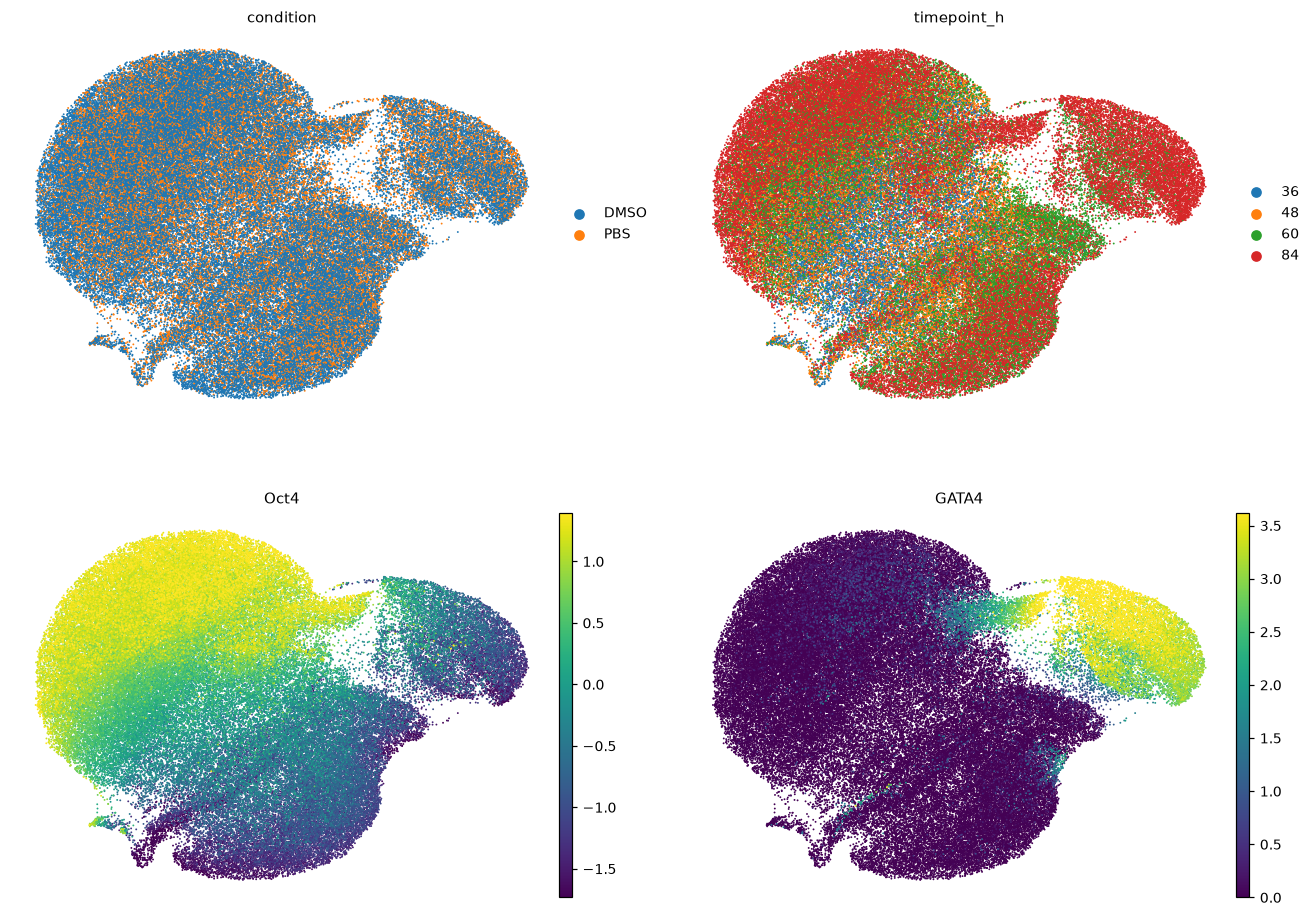

In [8]:
sc.pl.embedding(cells, basis="X_umap_identity", color=["condition", "timepoint_h", "Oct4", "GATA4"],
           ncols=2, s=6, frameon=False, cmap="viridis", vmin="p2", vmax="p98")

Secondly, we plot based on the full intensity marker set (`fullintensity`)

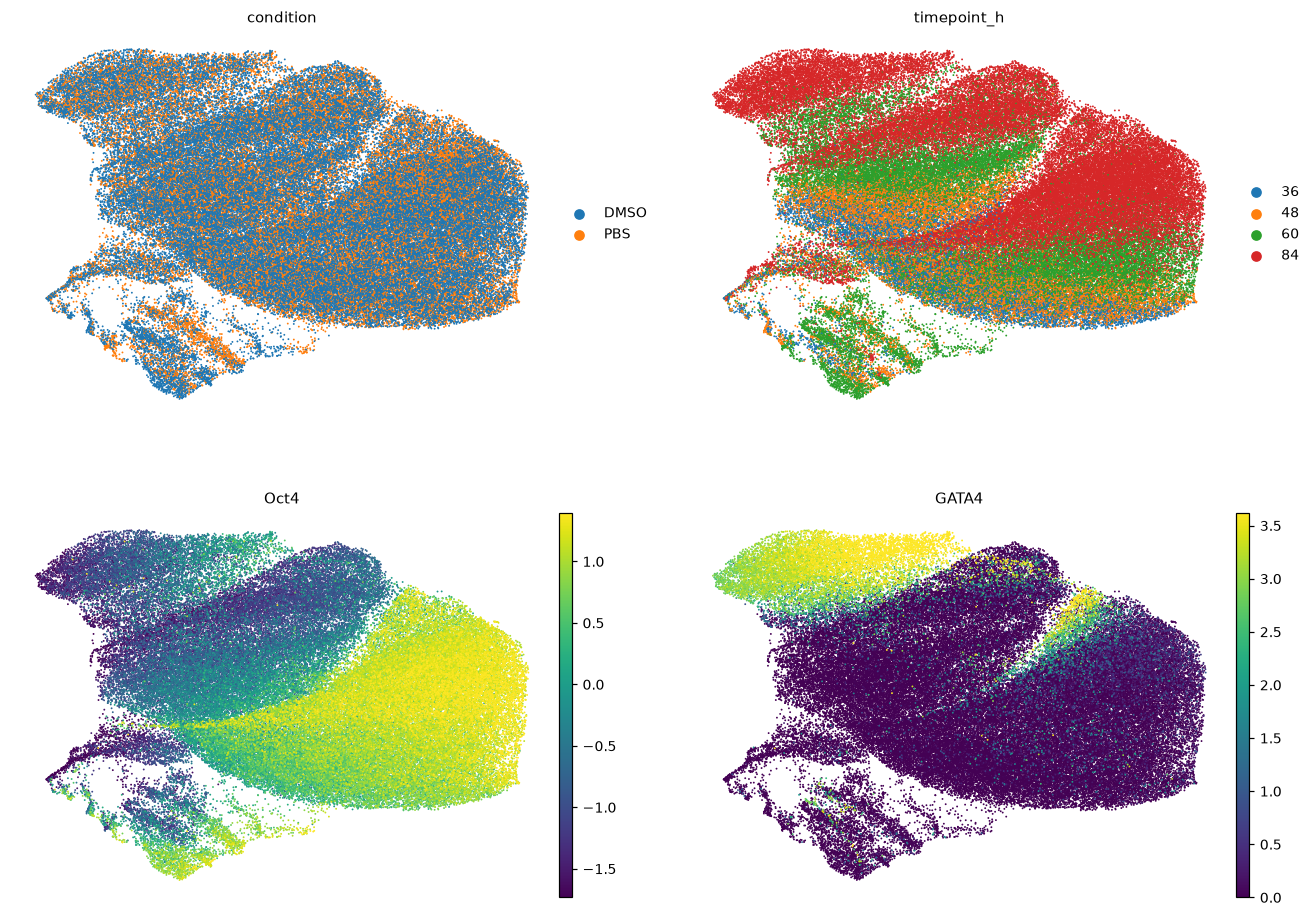

In [9]:
sc.pl.embedding(cells, basis="X_umap_fullintensity", color=["condition", "timepoint_h", "Oct4", "GATA4"],
           ncols=2, s=6, frameon=False, cmap="viridis", vmin="p2", vmax="p98")

### 3.2 Plotting using `sc.pl.umap()` requires an extra line

In this extra step we transfer the data stored in the custom obsm keys into `X_umap`, so that the function can resolve it.

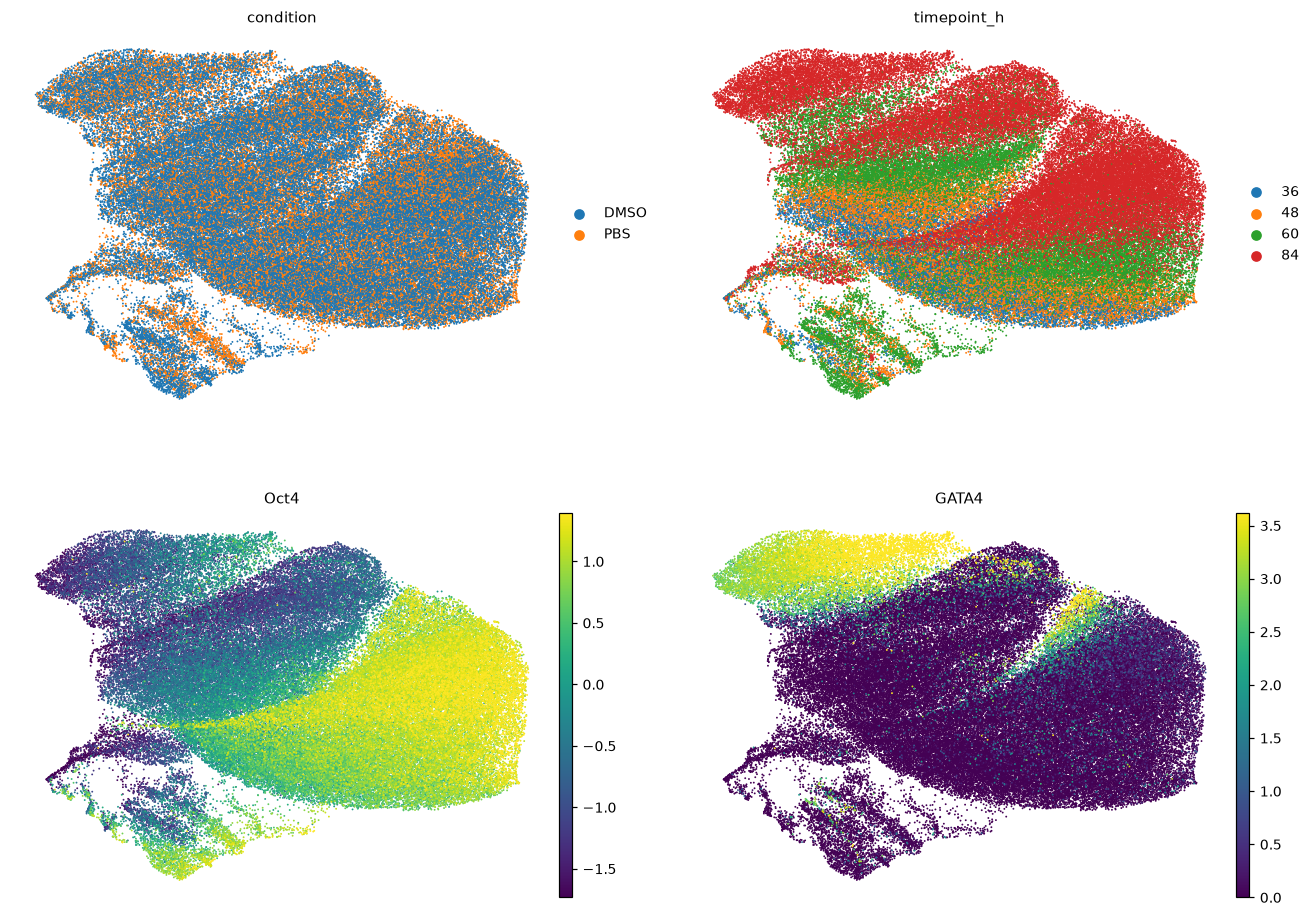

In [10]:
cells.obsm['X_umap'] = cells.obsm['X_umap_fullintensity'] # extra step

sc.pl.umap(cells, color=["condition", "timepoint_h", "Oct4", "GATA4"],
           ncols=2, s=6, frameon=False, cmap="viridis", vmin="p2", vmax="p98")

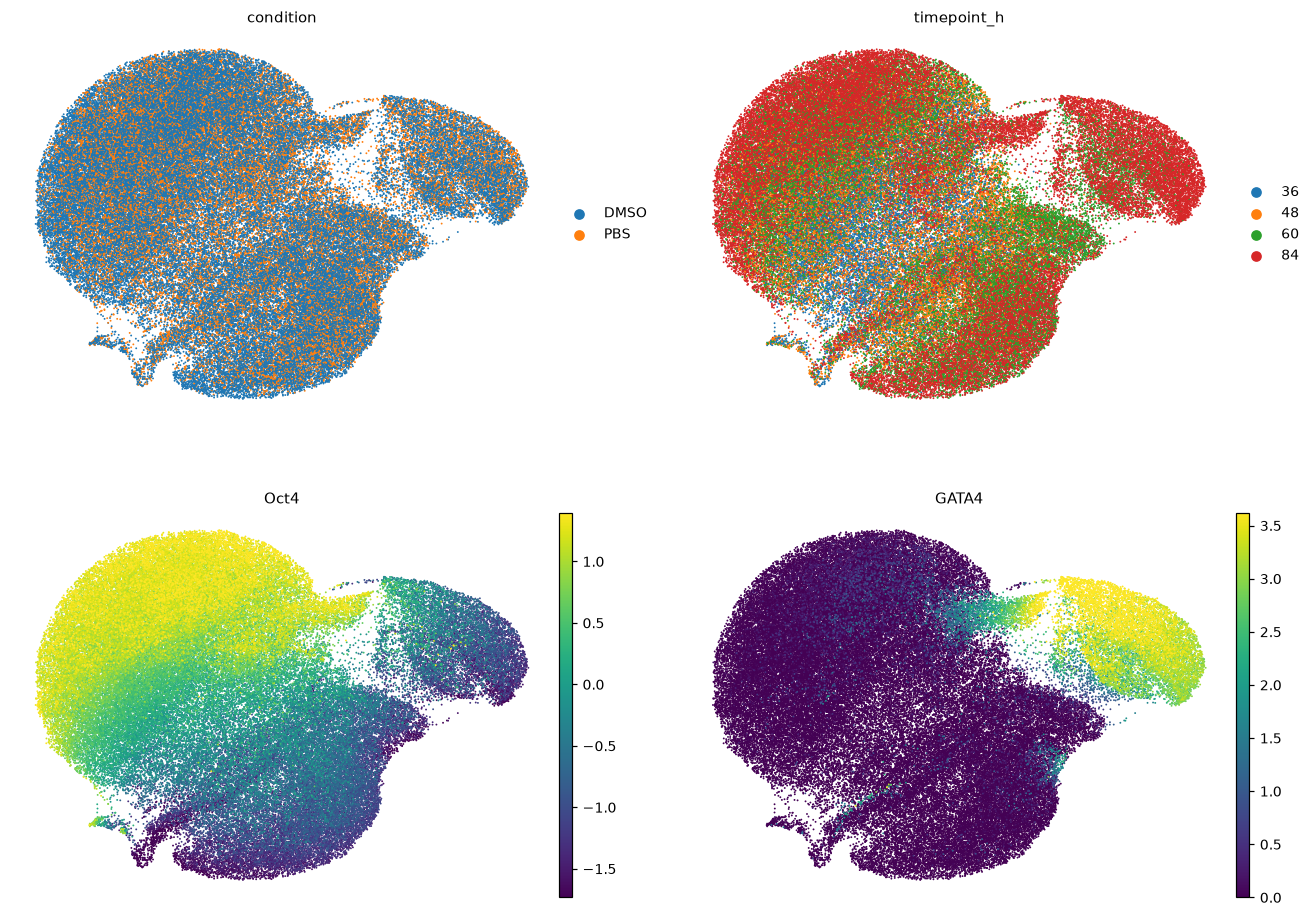

In [11]:
cells.obsm['X_umap'] = cells.obsm['X_umap_identity']
sc.pl.umap(cells, color=["condition", "timepoint_h", "Oct4", "GATA4"],
           ncols=2, s=6, frameon=False, cmap="viridis", vmin="p2", vmax="p98")

`vmin`/`vmax` are used because intensities have long tails — one cell 30 SDs above the
control will take the whole colour bar and leave every other cell the same shade of dark
blue. Clipping to the 2nd and 98th percentiles shows the structure instead of the
outlier

### The same thing by hand

`sc.pl.umap` is convenient and inflexible. Once you want two conditions picked out
against a grey background, or a colour bar clipped to a range, draw it yourself — it is
a scatter plot of two columns.

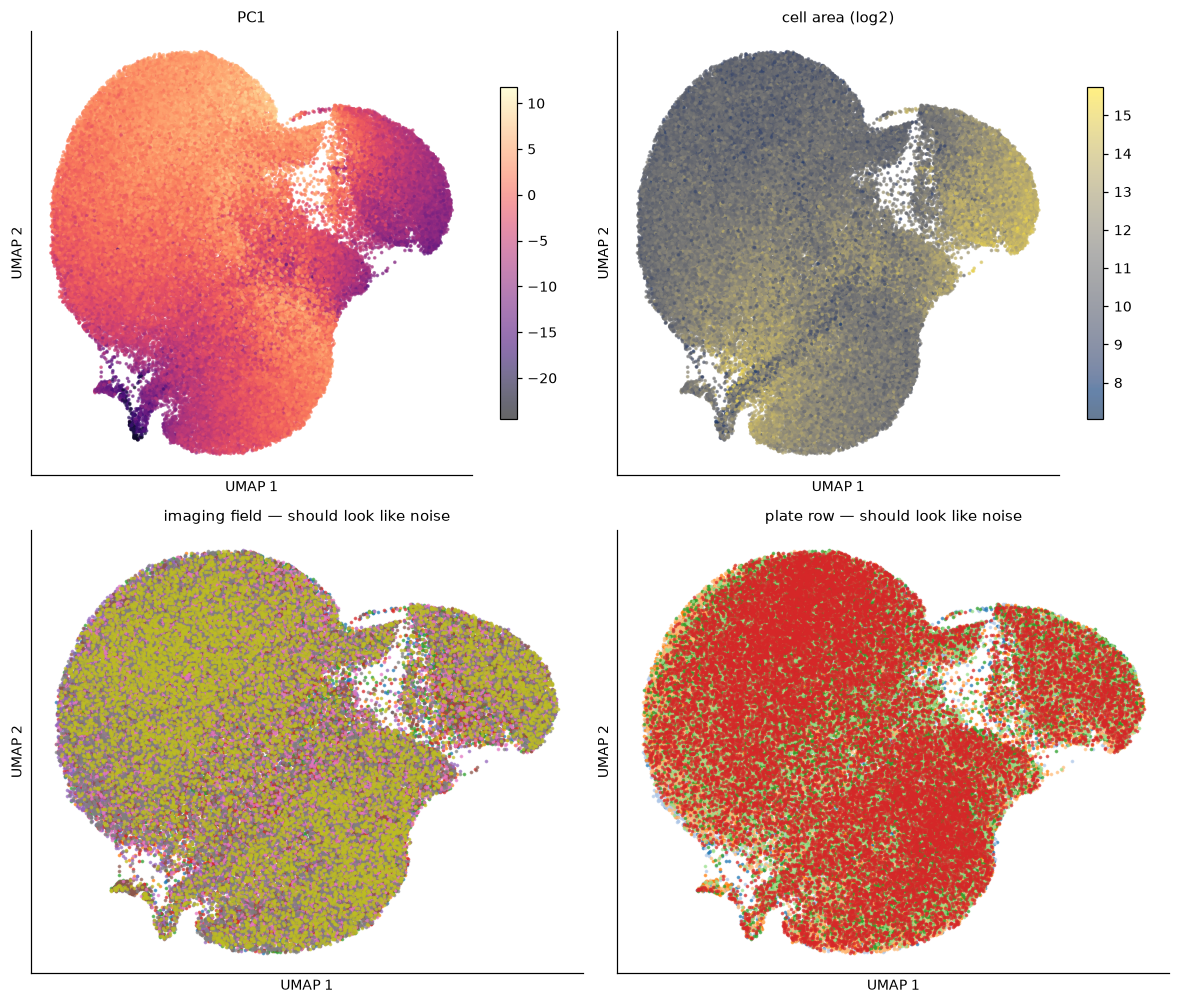

In [12]:
coords = cells.obsm["X_umap_identity"]

fig, axes = panel_grid(4, ncols=2, size=(5.4, 4.6))

s = axes[0].scatter(coords[:, 0], coords[:, 1], c=cells.obsm["X_pca"][:, 0],
                    cmap="magma", s=2, alpha=0.6)
axes[0].set_title("PC1"); fig.colorbar(s, ax=axes[0], shrink=0.75)

s = axes[1].scatter(coords[:, 0], coords[:, 1], c=np.log2(cells.obs.area),
                    cmap="cividis", s=2, alpha=0.6)
axes[1].set_title("cell area (log2)"); fig.colorbar(s, ax=axes[1], shrink=0.75)

fields = cells.obs.ROI.astype(str)
for value, colour in zip(sorted(fields.unique()), plt.cm.tab10.colors):
    mask = (fields == value).values
    axes[2].scatter(coords[mask, 0], coords[mask, 1], s=2, alpha=0.6, color=colour)
axes[2].set_title("imaging field — should look like noise")

rows = cells.obs.row.astype(str)
for value, colour in zip(sorted(rows.unique()), plt.cm.tab20.colors):
    mask = (rows == value).values
    axes[3].scatter(coords[mask, 0], coords[mask, 1], s=2, alpha=0.6, color=colour)
axes[3].set_title("plate row — should look like noise")

for ax in axes:
    ax.set(xticks=[], yticks=[], xlabel="UMAP 1", ylabel="UMAP 2")
fig.tight_layout()

The last panel is a control, and worth making a habit. **Plate row is not biology.** If
the map separates by row, or by well, or by imaging field, you are looking at a batch
effect and everything else on the picture is suspect.

## 4 · What UMAP does *not* preserve

Three things people read off UMAPs that are not there:

**Distance between clusters is not meaningful.** Two blobs far apart are not "more
different" than two blobs close together. UMAP optimises local neighbourhoods and lets
global geometry fall where it may.

**Cluster size is not meaningful.** A dense island can hold fewer cells than a sparse
smear. Area on the page reflects the embedding's local scaling, not cell counts.

**The shape is not stable.** Change the seed or `n_neighbors` and the picture rearranges
while the underlying data has not moved.

## 5 · Save the embedding

`obsm["X_umap"]` and both graphs in `obsp` travel with the object. Chapters 08, 09 and 10
reuse the `identity` graph rather than recomputing it.

In [13]:
cells.write_h5ad(DATA / "mcs2026_controls_downstream.h5ad", compression="gzip")
print(f"  obsm : {list(cells.obsm)}")
print(f"  obsp : {list(cells.obsp)}")
print(f"  uns  : {sorted(cells.uns)}")

  obsm : ['X_pca', 'X_identity', 'X_pca_full', 'X_umap_fullintensity', 'X_umap_identity', 'X_umap']
  obsp : ['identity_distances', 'identity_connectivities', 'fullintensity_distances', 'fullintensity_connectivities']
  uns  : ['X_pca_full', 'X_umap_fullintensity', 'X_umap_identity', 'condition_colors', 'decode_report', 'dropped_wells', 'fullintensity', 'identity', 'panels', 'pca', 'provenance', 'row_colors', 'subset_conditions', 'subset_of', 'subset_reason', 'themes', 'timepoint_h_colors']


---

## Exercises

### 1. How much does `n_neighbors` change your reading?

Run UMAP at `n_neighbors` = 5, 15 and 50, holding the seed fixed. Which features of the
picture survive all three?

:::{admonition} Solution
:class: dropdown

Small values shatter the map into many small islands; large values merge everything into
a few continents. What tends to survive is the *ordering* — if timepoints lie along a
gradient at 15, they usually still do at 50.

A practical rule: only report structure that is stable across at least two settings, and
say which you used.
:::

### 2. Does the whole plate look like this?

Embed a geosketch of all eighteen conditions — `mcs2026_sketch.h5ad` — the same way, and
put the two maps side by side. What is present in one and not the other?

:::{admonition} Solution
:class: dropdown

```python
plate = sc.read_h5ad(DATA / "mcs2026_sketch.h5ad")
sc.pp.pca(plate, n_comps=20, random_state=0)
sc.pp.neighbors(plate, n_neighbors=15, n_pcs=15, random_state=0)
sc.tl.umap(plate, random_state=0)
sc.pl.umap(plate, color=["timepoint_h", "Oct4"], s=6, frameon=False)
```
:::

### 3. Colour it by something that should mean nothing

Colour the map by `ROI` (the imaging field within a well) and by `label` (the
segmentation index). What would it mean if either of them showed structure?

:::{admonition} Solution
:class: dropdown

Both should look like noise. `ROI` showing structure would mean position within the well
affects the measurement — an illumination or focus artefact. `label` showing structure
would be stranger still, since it is only an ordering assigned by the segmentation, and
would point at something systematic in how objects were numbered.

Negative controls like these cost one line each and are the cheapest protection against
reporting an artefact.
:::

---

**Next:** [08 · Cell-type annotation](08_cell_type_annotation.ipynb).